In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import pickle
import os


In [6]:
#setting up plotting styles so our figures look clean and neat

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = [8,5]

In [12]:
df = pd.read_csv("../data/Mall_Customers.csv")

In [ ]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.shape

(200, 5)

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [14]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

# EDA

Text(0.5, 1.0, 'Age Distribution')

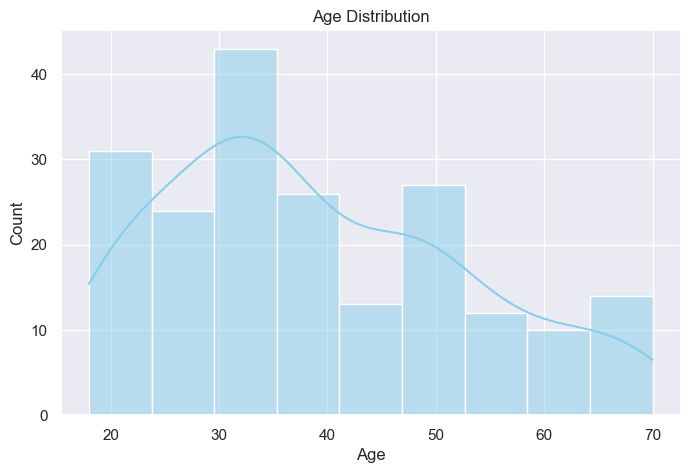

In [15]:
# Age Distribution

sns.histplot(data=df, x='Age', kde=True, color='skyblue')
plt.title("Age Distribution")

Text(0.5, 1.0, 'Annual Income (k$)')

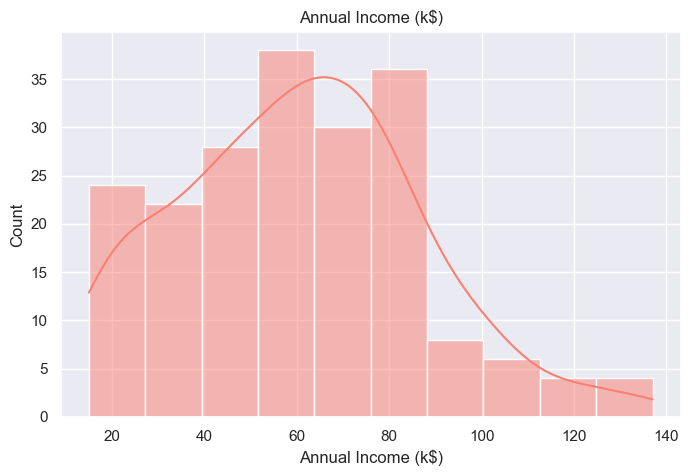

In [16]:
# Annual Income Distribution

sns.histplot(data=df, x="Annual Income (k$)", kde = True, color="salmon" )
plt.title("Annual Income (k$)")

Text(0.5, 1.0, 'Spending Score (1-100)')

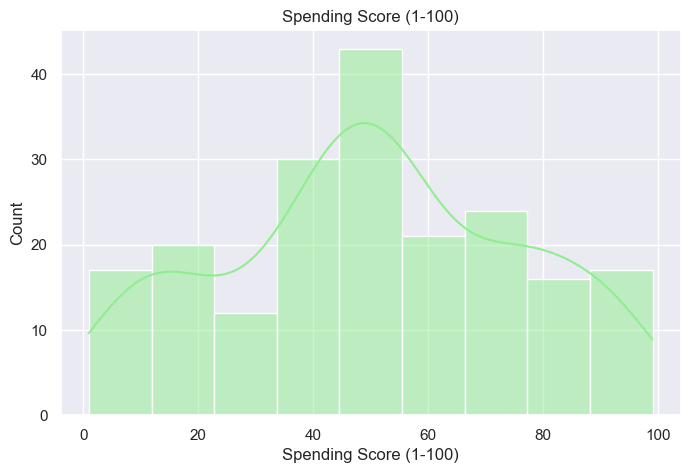

In [17]:
# Spending Score Distribution

sns.histplot(data=df, x="Spending Score (1-100)", kde=True, color='lightgreen')
plt.title("Spending Score (1-100)")

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

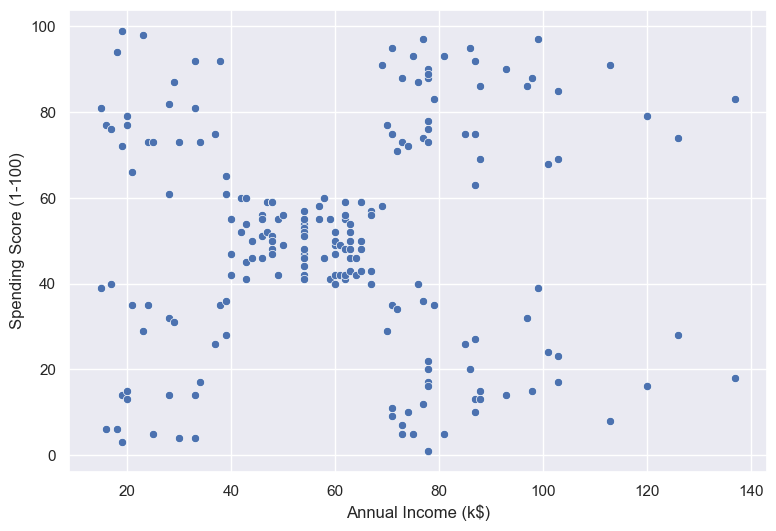

In [18]:
# plotting Income against Spending score

plt.figure(figsize=(9,6))
sns.scatterplot(data=df, x='Annual Income (k$)', y = 'Spending Score (1-100)' )

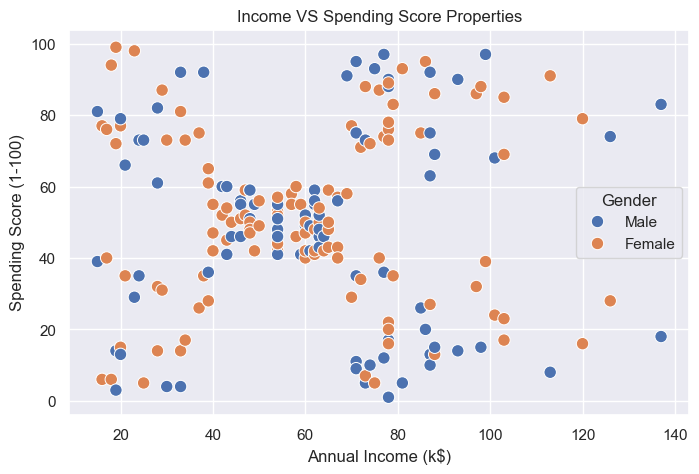

In [19]:
sns.scatterplot(data=df, x='Annual Income (k$)', y = 'Spending Score (1-100)' , hue = 'Gender', s=80)

plt.title("Income VS Spending Score Properties")
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Gender')
plt.show()

##### - By looking at this scatterplot, the datapoints naturally forms 5 distinct groups

## Selecting features and The Elbow method

In [20]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [21]:
X = df.iloc[:, 3:5]

In [22]:
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [23]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)

    #kmeans.inertia_ calculates the wcss score for the current cluster setup
    wcss.append(kmeans.inertia_)

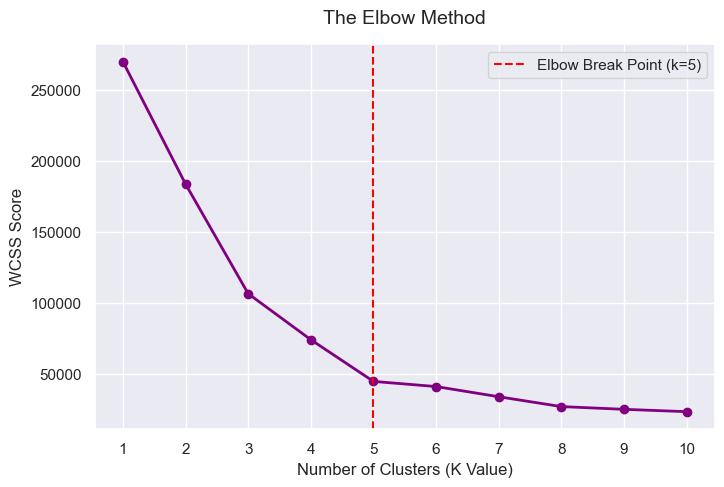

In [24]:
#plotting our wcss score to find the optimal "bend" point

plt.plot(range(1,11), wcss, marker = 'o', color='purple', linestyle='-', linewidth=2)
plt.title("The Elbow Method", fontsize=14, pad=15)
plt.xlabel("Number of Clusters (K Value)")
plt.ylabel('WCSS Score')
plt.xticks(range(1,11))
plt.axvline(x=5, color='red', linestyle='--', label='Elbow Break Point (k=5)')
plt.legend()
plt.show()

##### By the Elbow method the optimal k value is 5

## Training The Model

In [25]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X)

In [26]:
y_kmeans

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [27]:
pd.Series(y_kmeans).value_counts()

0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64

In [28]:
cluster_labels = [
    'Sensible Shoppers (Low Income, Low Spend)',
    'Standard Class (Mid Income, Mid Spend)',
    'Target High-Class (High Income, High Spend)',
    'Careless Spenders (Low Income, High Spend)',
    'Careful Savers (High Income, Low Spend)'
]

colors = ['red','blue','green','orange', 'magenta']

In [29]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


C:\Users\Shreya\AppData\Local\Temp\ipykernel_17616\1726586268.py:4: UserWarning: You passed a edgecolor/edgecolors ('white') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=250, c='black', marker='x', edgecolor='white', label = 'Group Centers (Centroids)')


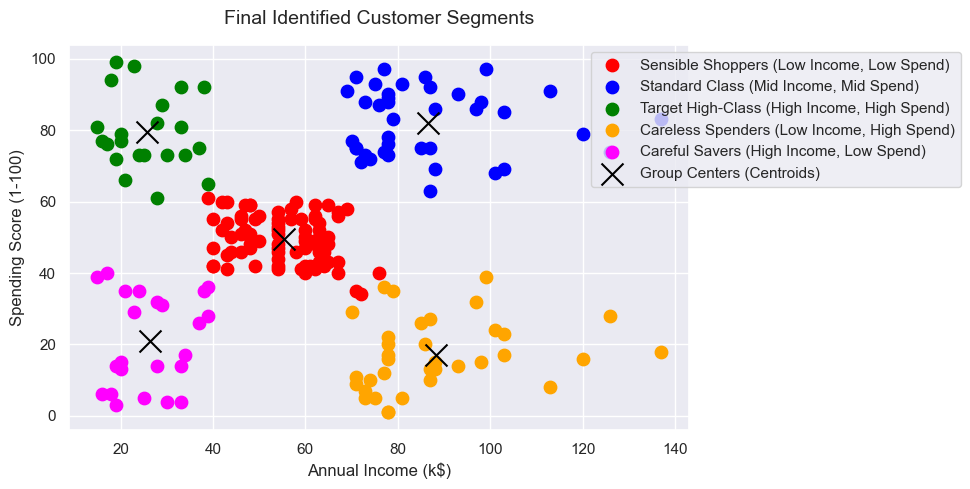

In [30]:
for i in range(5):
    plt.scatter(X.iloc[y_kmeans == i, 0], X.iloc[y_kmeans == i, 1], s=80, c=colors[i], label=cluster_labels[i])

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=250, c='black', marker='x', edgecolor='white', label = 'Group Centers (Centroids)')

plt.title('Final Identified Customer Segments', fontsize = 14, pad=15)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(loc='upper right', bbox_to_anchor=(1.45, 1))
# plt.tight_layout()

plt.show()

In [31]:
import pickle

In [32]:
with open('customer_kmeans_model.pkl', 'wb') as file:
    pickle.dump(kmeans, file)

In [33]:
with open('customer_kmeans_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

In [34]:
loaded_model.predict([[500,60]])

d:\End-To-End projects\customer_segmentation_project\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


array([3], dtype=int32)

In [35]:
# Let's print out the exact center coordinates for each cluster number
for i, center in enumerate(kmeans.cluster_centers_):
    print(f"Cluster {i}: Income = {center[0]:.1f}k$, Spending Score = {center[1]:.1f}")
    

Cluster 0: Income = 55.3k$, Spending Score = 49.5
Cluster 1: Income = 86.5k$, Spending Score = 82.1
Cluster 2: Income = 25.7k$, Spending Score = 79.4
Cluster 3: Income = 88.2k$, Spending Score = 17.1
Cluster 4: Income = 26.3k$, Spending Score = 20.9
